# Projeto de Aprendizado Não Supervisionado  
## Segmentação de perfis de estudantes

Este notebook aplica **aprendizado não supervisionado** ao arquivo `student_performance.csv`.

O objetivo principal é identificar grupos de estudantes com comportamentos e características semelhantes, sem fornecer ao algoritmo uma resposta correta previamente definida.

### Pergunta central

> Existem perfis distintos de estudantes considerando hábitos de estudo, frequência, motivação, acesso a recursos, participação e uso de tecnologia?

### Técnicas utilizadas

1. Análise exploratória dos dados;
2. Preparação e padronização das variáveis;
3. **K-Means**;
4. Método do cotovelo;
5. **Silhouette Score**;
6. Redução de dimensionalidade com **PCA**;
7. Clusterização hierárquica;
8. Interpretação e nomeação dos clusters.

O notebook foi estruturado como material didático: antes de cada bloco de código há uma explicação do conceito, da função utilizada e da interpretação esperada.

# 1. Conceitos fundamentais

## 1.1 O que é aprendizado não supervisionado?

No aprendizado supervisionado, existe uma variável-alvo conhecida, como nota final, aprovação ou quantidade de vendas. O modelo aprende a prever essa resposta.

No **aprendizado não supervisionado**, não existe uma variável-alvo fornecida ao algoritmo. O objetivo é descobrir padrões internos nos dados.

Exemplos:

- segmentar clientes com comportamentos semelhantes;
- agrupar produtos por perfil de preço e demanda;
- identificar perfis de estudantes;
- detectar observações fora do padrão;
- reduzir a quantidade de dimensões de um conjunto de dados.

## 1.2 O que é clusterização?

Clusterização é o processo de dividir as observações em grupos chamados **clusters**.

Um bom agrupamento busca:

- alta semelhança entre elementos do mesmo cluster;
- baixa semelhança entre elementos de clusters diferentes.

Os números atribuídos aos clusters, como `0`, `1` e `2`, não possuem significado próprio. O analista precisa estudar as características de cada grupo e interpretá-las.

## 1.3 Como funciona o K-Means?

O K-Means é um algoritmo de clusterização baseado em distância.

De forma simplificada:

1. Escolhemos a quantidade de clusters `k`;
2. O algoritmo cria `k` centroides iniciais;
3. Cada observação é associada ao centroide mais próximo;
4. Os centroides são recalculados com a média dos pontos do grupo;
5. O processo é repetido até os grupos se estabilizarem.

### Limitação importante

O K-Means utiliza distância euclidiana. Por isso, variáveis em escalas muito diferentes precisam ser padronizadas.

Sem padronização, uma variável como `Attendance`, medida de 60 a 100, poderia dominar uma variável binária medida entre 0 e 1.

# 2. Importação das bibliotecas

In [4]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42

### Explicação das principais bibliotecas

- `pandas`: leitura, organização e análise de tabelas;
- `numpy`: operações numéricas;
- `matplotlib` e `seaborn`: criação de gráficos;
- `StandardScaler`: padronização das variáveis numéricas;
- `OneHotEncoder`: transformação de categorias em colunas binárias;
- `KMeans`: algoritmo principal de clusterização;
- `silhouette_score`: métrica de qualidade dos clusters;
- `PCA`: redução da dimensionalidade;
- `AgglomerativeClustering`: clusterização hierárquica;
- `dendrogram`: representação visual da hierarquia entre observações.

# 3. Carregamento do dataset

In [6]:
df_original = pd.read_csv('student_performance.csv')
df = df_original.copy()

print(f"Quantidade de linhas: {df.shape[0]:,}")
print(f"Quantidade de colunas: {df.shape[1]}")

Quantidade de linhas: 14,003
Quantidade de colunas: 16


### Por que criar `df_original` e `df`?

- `df_original` preserva os dados exatamente como foram carregados;
- `df` é a cópia utilizada nas transformações.

Essa prática permite recuperar o dataset original sem precisar ler o arquivo novamente.

In [ ]:
df.head()

,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


`head()` mostra, por padrão, as cinco primeiras linhas. Ele ajuda a verificar:

- se o arquivo foi lido corretamente;
- como os valores estão organizados;
- quais colunas são numéricas ou codificadas;
- se existem valores estranhos logo no início.

# 4. Dicionário das variáveis

O dataset possui variáveis de comportamento, contexto, tecnologia e desempenho.

| Coluna | Interpretação geral |
|---|---|
| `StudyHours` | Horas de estudo por semana|
| `Attendance` | Frequência às aulas |
| `Resources` | Nível de acesso a recursos |
| `Extracurricular` | Participação em atividade extracurricular |
| `Motivation` | Nível codificado de motivação |
| `Internet` | Acesso à internet |
| `Gender` | Gênero codificado |
| `Age` | Idade |
| `LearningStyle` | Estilo de aprendizagem codificado |
| `OnlineCourses` | Quantidade de cursos on-line |
| `Discussions` | Participação em discussões |
| `AssignmentCompletion` | Percentual de atividades concluídas |
| `ExamScore` | Nota em prova |
| `EduTech` | Uso de tecnologia educacional |
| `StressLevel` | Nível codificado de estresse |
| `FinalGrade` | Faixa codificada da nota final |

> Algumas categorias estão representadas por números. Os códigos são tratados de acordo com sua natureza estatística.

# 5. Inspeção e qualidade dos dados

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            14003 non-null  int64
dtypes: i

`info()` apresenta:

- número de linhas;
- nomes das colunas;
- quantidade de valores não nulos;
- tipo de cada coluna;
- memória utilizada.

Neste arquivo todas as colunas foram lidas como inteiras. Isso não significa que todas sejam quantitativas: algumas são categorias representadas por códigos.

In [ ]:
quality = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "nulos": df.isna().sum(),
    "nulos_pct": (df.isna().mean() * 100).round(2),
    "valores_unicos": df.nunique()
})

quality

,tipo,nulos,nulos_pct,valores_unicos
StudyHours,int64,0,0.0,37
Attendance,int64,0,0.0,41
Resources,int64,0,0.0,3
Extracurricular,int64,0,0.0,2
Motivation,int64,0,0.0,3
Internet,int64,0,0.0,2
Gender,int64,0,0.0,2
Age,int64,0,0.0,12
LearningStyle,int64,0,0.0,4
OnlineCourses,int64,0,0.0,21


### Funções utilizadas

- `isna()`: marca valores ausentes;
- `sum()`: conta os valores marcados como ausentes;
- `mean()`: calcula a proporção de ausentes;
- `nunique()`: conta quantos valores diferentes existem em cada coluna;
- `DataFrame()`: constrói uma nova tabela.

A quantidade de valores únicos ajuda a distinguir variáveis contínuas de variáveis categóricas codificadas.

In [ ]:
print("Quantidade de linhas duplicadas:", df.duplicated().sum())

Quantidade de linhas duplicadas: 1534


## 5.1 Tratamento de duplicatas

Uma linha duplicada é uma linha em que todos os valores são iguais a outra linha.

Duplicatas podem representar:

- repetição acidental;
- registros legítimos de estudantes diferentes com características idênticas.

Como o dataset não possui um identificador único do estudante, não podemos provar que todas as duplicatas são erros. Para este exercício, criaremos uma versão sem duplicatas e registraremos explicitamente essa decisão.

In [8]:
df_clean = df.drop_duplicates().reset_index(drop=True)

print(f"Linhas antes da remoção: {len(df):,}")
print(f"Linhas após a remoção: {len(df_clean):,}")
print(f"Linhas removidas: {len(df) - len(df_clean):,}")

Linhas antes da remoção: 14,003
Linhas após a remoção: 12,469
Linhas removidas: 1,534


- `drop_duplicates()` remove linhas completamente repetidas;
- `reset_index(drop=True)` recria o índice de 0 até o final;
- `drop=True` evita que o índice antigo vire uma nova coluna.

Em um projeto real, essa remoção deveria ser confirmada com quem conhece a origem dos dados.

# 6. Estatísticas descritivas

In [9]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
StudyHours,12469.0,20.034405,6.049485,5.0,16.0,20.0,24.0,44.0
Attendance,12469.0,80.239233,11.469028,60.0,70.0,80.0,90.0,100.0
Resources,12469.0,1.101371,0.711171,0.0,1.0,1.0,2.0,2.0
Extracurricular,12469.0,0.583126,0.493061,0.0,0.0,1.0,1.0,1.0
Motivation,12469.0,0.907370,0.709599,0.0,0.0,1.0,1.0,2.0
Internet,12469.0,0.917074,0.275781,0.0,1.0,1.0,1.0,1.0
Gender,12469.0,0.538616,0.498527,0.0,0.0,1.0,1.0,1.0
Age,12469.0,23.529152,3.510956,18.0,20.0,24.0,27.0,29.0
LearningStyle,12469.0,1.515358,1.116071,0.0,1.0,2.0,3.0,3.0
OnlineCourses,12469.0,9.872404,6.114025,0.0,5.0,10.0,15.0,20.0


`describe()` calcula:

- `count`: quantidade de observações;
- `mean`: média;
- `std`: desvio padrão;
- `min`: mínimo;
- `25%`: primeiro quartil;
- `50%`: mediana;
- `75%`: terceiro quartil;
- `max`: máximo.

O `.T` transpõe a tabela para deixar uma variável por linha, facilitando a leitura.

# 7. Análise exploratória

## 7.1 Distribuição das variáveis quantitativas

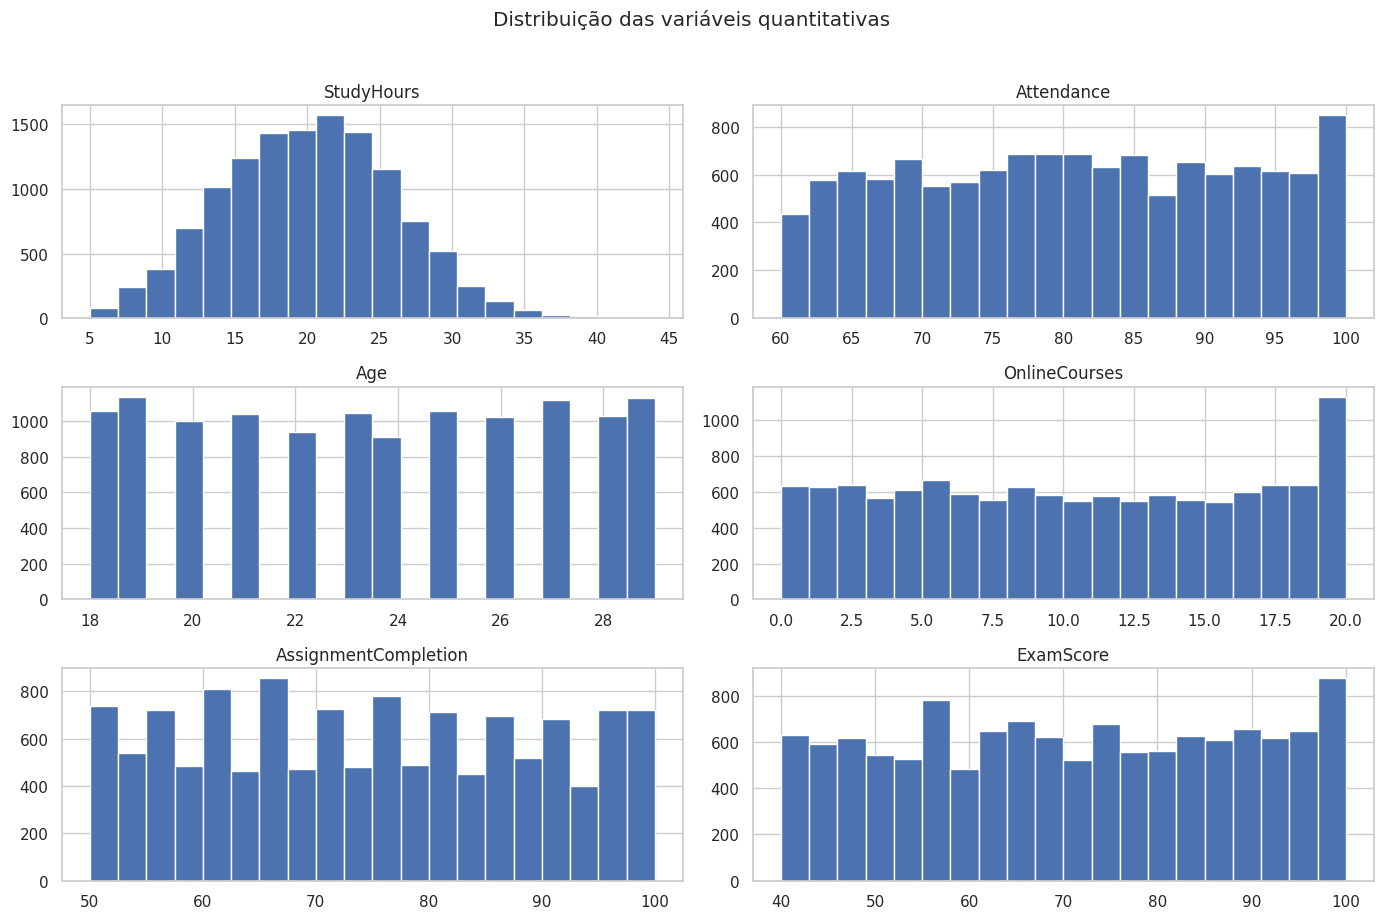

In [10]:
continuous_cols = [
    "StudyHours",
    "Attendance",
    "Age",
    "OnlineCourses",
    "AssignmentCompletion",
    "ExamScore"
]

df_clean[continuous_cols].hist(figsize=(14, 9), bins=20)
plt.suptitle("Distribuição das variáveis quantitativas", y=1.02)
plt.tight_layout()
plt.show()

### Como interpretar os histogramas

- eixo X: intervalos de valores;
- eixo Y: frequência de observações;
- picos: faixas com maior concentração;
- caudas: valores mais extremos;
- assimetria: concentração maior em um dos lados.

O parâmetro `bins=20` divide cada variável em 20 intervalos.

## 7.2 Correlação

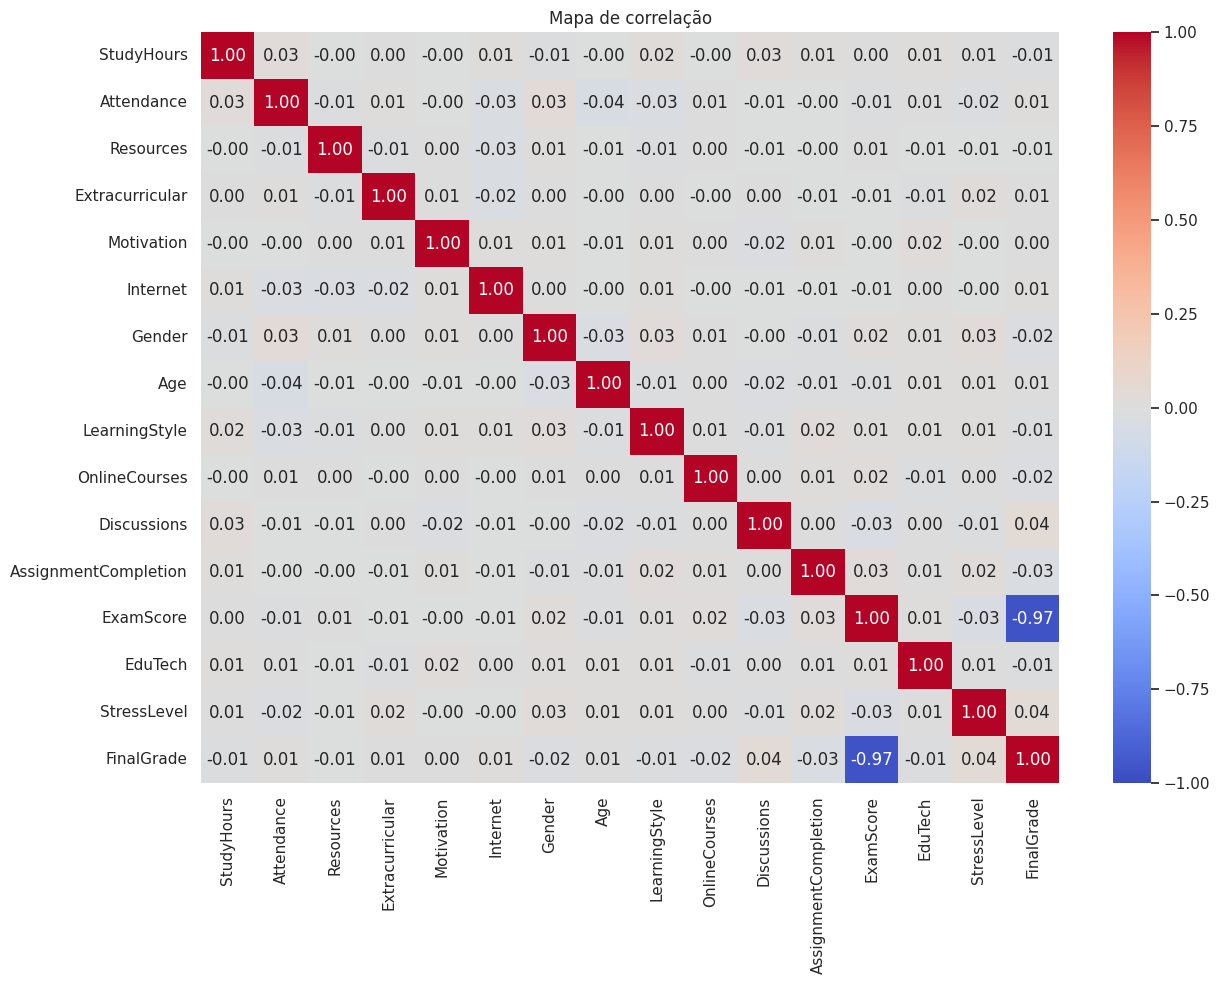

In [11]:
corr = df_clean.corr(numeric_only=True)

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)
plt.title("Mapa de correlação")
plt.tight_layout()
plt.show()

A correlação de Pearson varia entre -1 e 1:

- próxima de 1: relação linear positiva;
- próxima de -1: relação linear negativa;
- próxima de 0: pouca ou nenhuma relação linear.

Correlação não significa causalidade.

Além disso, várias colunas são códigos categóricos. Nesses casos, a correlação numérica deve ser interpretada com cautela, pois a distância entre os códigos pode não possuir significado real.

# 8. Escolha das variáveis para clusterização

O objetivo será agrupar estudantes por **perfil de comportamento e contexto educacional**.

Não usaremos `ExamScore` nem `FinalGrade` para formar os clusters. Essas variáveis serão usadas depois para interpretar os resultados.

Essa separação é importante:

- variáveis de entrada formam os grupos;
- variáveis de desempenho ajudam a verificar se os grupos apresentam resultados diferentes.

Também excluímos `Gender`, pois o objetivo é construir segmentos educacionais acionáveis, e não grupos demográficos.

### Variáveis usadas

**Numéricas/ordinais:**

- `StudyHours`;
- `Attendance`;
- `Resources`;
- `Motivation`;
- `Age`;
- `OnlineCourses`;
- `AssignmentCompletion`;
- `StressLevel`.

**Categóricas:**

- `Extracurricular`;
- `Internet`;
- `LearningStyle`;
- `Discussions`;
- `EduTech`.

In [13]:
numeric_features = [
    "StudyHours",
    "Attendance",
    "Resources",
    "Motivation",
    "Age",
    "OnlineCourses",
    "AssignmentCompletion",
    "StressLevel"
]

categorical_features = [
    "Extracurricular",
    "Internet",
    "LearningStyle",
    "Discussions",
    "EduTech"
]

features = numeric_features + categorical_features

X = df_clean[features].copy()

print("Formato da matriz original:", X.shape)
X.head()

Formato da matriz original: (12469, 13)


,StudyHours,Attendance,Resources,Motivation,Age,OnlineCourses,AssignmentCompletion,StressLevel,Extracurricular,Internet,LearningStyle,Discussions,EduTech
0,19,64,1,0,19,8,59,1,0,1,2,1,0
1,19,64,1,0,23,16,90,1,0,1,3,0,0
2,19,64,1,0,28,19,67,1,0,1,1,0,1
3,19,64,1,0,19,8,59,1,1,1,2,1,0
4,19,64,1,0,23,16,90,1,1,1,3,0,0


# 9. Pré-processamento

## 9.1 Por que padronizar?

O K-Means calcula distâncias. Se uma variável varia entre 0 e 100 e outra entre 0 e 1, a primeira pode dominar o agrupamento.

O `StandardScaler` transforma cada variável numérica aproximadamente para:

- média igual a 0;
- desvio padrão igual a 1.

A transformação é:

\[
z = \frac{x - \mu}{\sigma}
\]

## 9.2 Por que usar One-Hot Encoding?

Uma categoria como `LearningStyle = 3` não deve ser interpretada como “três vezes maior” que `LearningStyle = 1`.

O `OneHotEncoder` cria uma coluna binária para cada categoria, evitando uma ordem artificial.

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Formato antes do pré-processamento:", X.shape)
print("Formato depois do pré-processamento:", X_processed.shape)

Formato antes do pré-processamento: (12469, 13)
Formato depois do pré-processamento: (12469, 20)


### Funções e objetos

- `ColumnTransformer`: aplica transformações diferentes a conjuntos de colunas;
- `fit_transform()`: aprende os parâmetros da transformação e transforma os dados;
- `StandardScaler`: aprende média e desvio padrão;
- `OneHotEncoder`: aprende as categorias existentes;
- `handle_unknown="ignore"`: impede erro se uma categoria nova aparecer posteriormente.

In [15]:
feature_names = preprocessor.get_feature_names_out()
feature_names[:20]

array(['num__StudyHours', 'num__Attendance', 'num__Resources',
       'num__Motivation', 'num__Age', 'num__OnlineCourses',
       'num__AssignmentCompletion', 'num__StressLevel',
       'cat__Extracurricular_0', 'cat__Extracurricular_1',
       'cat__Internet_0', 'cat__Internet_1', 'cat__LearningStyle_0',
       'cat__LearningStyle_1', 'cat__LearningStyle_2',
       'cat__LearningStyle_3', 'cat__Discussions_0', 'cat__Discussions_1',
       'cat__EduTech_0', 'cat__EduTech_1'], dtype=object)

`get_feature_names_out()` mostra os nomes das colunas criadas depois das transformações.

Os prefixos:

- `num__`: variável numérica padronizada;
- `cat__`: variável categórica convertida em indicador binário.

# 10. Escolha da quantidade de clusters

O K-Means exige que o analista escolha `k`.

Usaremos duas abordagens:

1. **Método do cotovelo**: observa a redução da inércia;
2. **Silhouette Score**: avalia separação e coesão dos clusters.

## 10.1 Método do cotovelo

In [16]:
# Para tornar a escolha de k rápida e reproduzível, usamos uma amostra.
rng = np.random.default_rng(RANDOM_STATE)
elbow_sample_size = min(2000, X_processed.shape[0])
elbow_indices = rng.choice(X_processed.shape[0], size=elbow_sample_size, replace=False)
X_elbow = X_processed[elbow_indices]

k_values = range(2, 9)
inertias = []
silhouette_scores = []

for k in k_values:
    model = KMeans(
        n_clusters=k,
        n_init=5,
        max_iter=150,
        random_state=RANDOM_STATE
    )

    labels = model.fit_predict(X_elbow)

    inertias.append(model.inertia_)
    silhouette_scores.append(
        silhouette_score(X_elbow, labels, sample_size=min(500, elbow_sample_size), random_state=RANDOM_STATE)
    )

elbow_results = pd.DataFrame({
    "k": list(k_values),
    "inercia": inertias,
    "silhouette": silhouette_scores
})

elbow_results.round(4)

,k,inercia,silhouette
0,2,18811.8571,0.0750
1,3,17740.9707,0.0644
2,4,17002.5741,0.0686
3,5,16414.2080,0.0661
4,6,15856.2439,0.0636
5,7,15469.7575,0.0674
6,8,15065.3591,0.0671


### O que cada parte faz?

- `range(2, 11)`: testa de 2 até 10 clusters;
- `KMeans(n_clusters=k)`: cria um modelo com `k` grupos;
- `n_init=20`: executa o algoritmo 20 vezes com centroides iniciais diferentes;
- `random_state`: torna o resultado reproduzível;
- `fit_predict()`: treina o modelo e devolve o cluster de cada linha;
- `inertia_`: soma das distâncias quadráticas dos pontos aos seus centroides;
- `silhouette_score()`: mede a qualidade da separação entre os grupos.

A inércia sempre diminui quando `k` aumenta. Procuramos um ponto em que a melhoria começa a ficar pequena: o “cotovelo”.

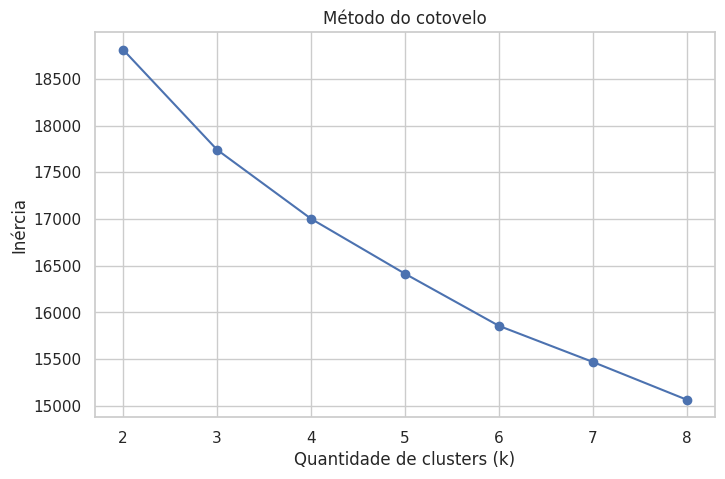

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(elbow_results["k"], elbow_results["inercia"], marker="o")
plt.title("Método do cotovelo")
plt.xlabel("Quantidade de clusters (k)")
plt.ylabel("Inércia")
plt.xticks(list(k_values))
plt.show()

## 10.2 Silhouette Score

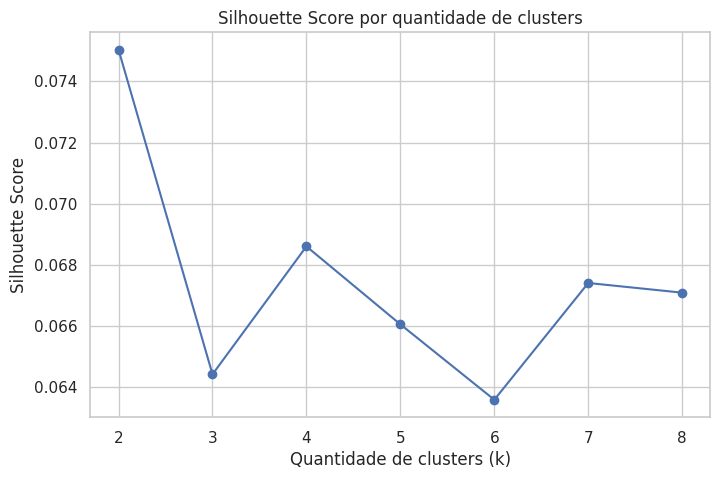

In [18]:
plt.figure(figsize=(8, 5))
plt.plot(elbow_results["k"], elbow_results["silhouette"], marker="o")
plt.title("Silhouette Score por quantidade de clusters")
plt.xlabel("Quantidade de clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_values))
plt.show()

O Silhouette Score varia aproximadamente entre -1 e 1:

- próximo de 1: clusters bem separados;
- próximo de 0: grupos sobrepostos;
- negativo: algumas observações podem ter sido atribuídas ao cluster errado.

Não existe um limite universal. Dados humanos e comportamentais costumam apresentar grupos menos separados do que conjuntos artificiais.

In [19]:
best_k_silhouette = int(
    elbow_results.loc[elbow_results["silhouette"].idxmax(), "k"]
)

print("Melhor k segundo o Silhouette Score:", best_k_silhouette)

Melhor k segundo o Silhouette Score: 2


Neste projeto, utilizaremos o valor indicado pelo maior Silhouette Score como escolha automática. Em uma análise profissional, a decisão final também deve considerar:

- utilidade prática dos segmentos;
- facilidade de interpretação;
- estabilidade dos resultados;
- conhecimento do domínio.

# 11. Treinamento do modelo K-Means final

In [20]:
k_final = best_k_silhouette

# Ajustamos o K-Means na amostra usada na escolha de k e depois
# atribuímos todos os estudantes ao centroide mais próximo.
kmeans = KMeans(
    n_clusters=k_final,
    n_init=5,
    max_iter=150,
    random_state=RANDOM_STATE
)

kmeans.fit(X_elbow)

df_clustered = df_clean.copy()
df_clustered["Cluster"] = kmeans.predict(X_processed)

df_clustered["Cluster"].value_counts().sort_index()

,count
Cluster,
0,5925
1,6544


A coluna `Cluster` contém o grupo atribuído a cada estudante.

Os rótulos são arbitrários. O cluster 0 não é necessariamente melhor ou pior que o cluster 1.

# 12. Tamanho dos clusters

In [21]:
cluster_sizes = (
    df_clustered["Cluster"]
    .value_counts()
    .sort_index()
    .rename("Quantidade")
    .to_frame()
)

cluster_sizes["Percentual"] = (
    cluster_sizes["Quantidade"] / len(df_clustered) * 100
).round(2)

cluster_sizes

,Quantidade,Percentual
Cluster,,
0,5925,47.52
1,6544,52.48


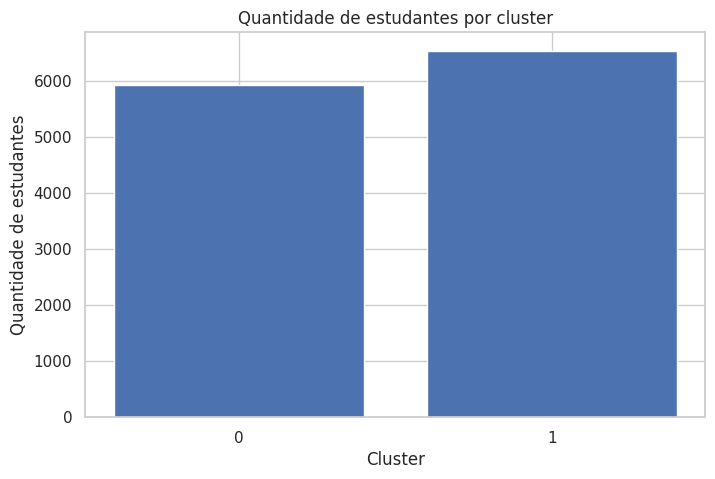

In [22]:
plt.figure(figsize=(8, 5))
plt.bar(
    cluster_sizes.index.astype(str),
    cluster_sizes["Quantidade"]
)
plt.title("Quantidade de estudantes por cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de estudantes")
plt.show()

# 13. Perfil dos clusters

A etapa mais importante da clusterização é a interpretação.

Calcularemos a média das variáveis em cada cluster. Também incluiremos `ExamScore` e `FinalGrade`, mas apenas para avaliar os resultados dos grupos depois que eles já foram formados.

In [23]:
profile_columns = numeric_features + [
    "ExamScore",
    "FinalGrade"
]

cluster_profile = (
    df_clustered
    .groupby("Cluster")[profile_columns]
    .mean()
    .round(2)
)

cluster_profile

,StudyHours,Attendance,Resources,Motivation,Age,OnlineCourses,AssignmentCompletion,StressLevel,ExamScore,FinalGrade
Cluster,,,,,,,,,,
0,20.4,80.03,1.18,0.95,23.25,9.96,87.58,1.32,70.95,1.41
1,19.7,80.43,1.03,0.87,23.78,9.79,62.69,1.29,69.73,1.49


`groupby("Cluster")` separa os estudantes por grupo.

`mean()` calcula o valor médio de cada variável dentro de cada cluster.

A tabela permite responder:

- qual grupo estuda mais;
- qual apresenta maior frequência;
- qual conclui mais atividades;
- qual possui maior estresse;
- como o desempenho varia entre os perfis.

## 13.1 Perfil relativo padronizado

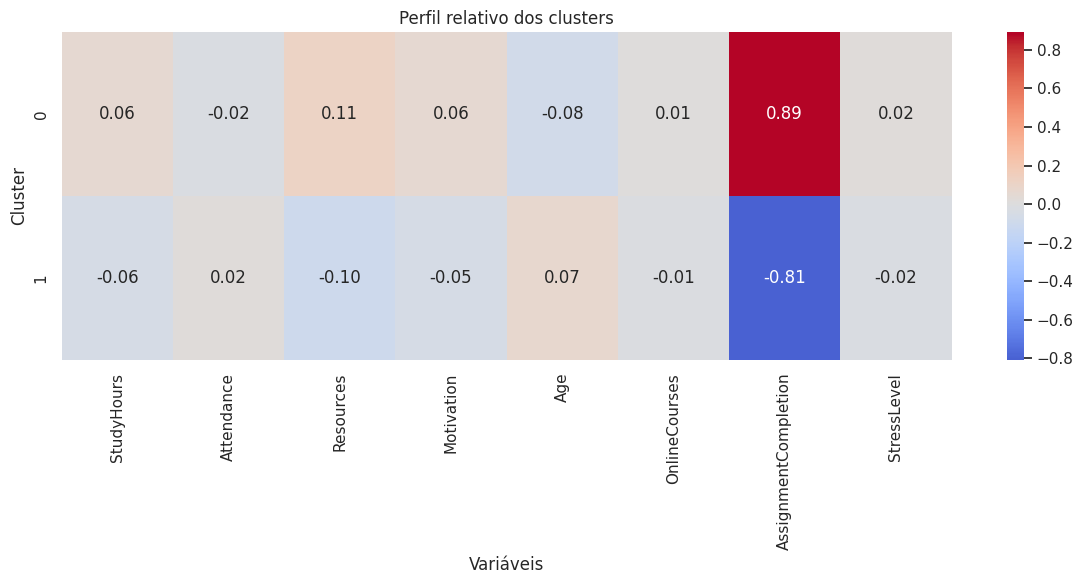

In [24]:
profile_for_heatmap = (
    cluster_profile[numeric_features]
    - df_clustered[numeric_features].mean()
) / df_clustered[numeric_features].std()

plt.figure(figsize=(12, 6))
sns.heatmap(
    profile_for_heatmap,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f"
)
plt.title("Perfil relativo dos clusters")
plt.xlabel("Variáveis")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()

Nesta tabela:

- valor positivo: média do cluster acima da média geral;
- valor negativo: média do cluster abaixo da média geral;
- valor próximo de zero: semelhante à média geral.

Essa visualização facilita a criação de nomes interpretáveis para os grupos.

## 13.2 Variáveis categóricas por cluster

In [25]:
categorical_profile = {}

for column in categorical_features:
    table = pd.crosstab(
        df_clustered["Cluster"],
        df_clustered[column],
        normalize="index"
    ).round(3)

    categorical_profile[column] = table
    print(f"\nDistribuição proporcional de {column}:")
    display(table)


Distribuição proporcional de Extracurricular:


Extracurricular,0,1
Cluster,,
0,0.416,0.584
1,0.418,0.582



Distribuição proporcional de Internet:


Internet,0,1
Cluster,,
0,0.084,0.916
1,0.082,0.918



Distribuição proporcional de LearningStyle:


LearningStyle,0,1,2,3
Cluster,,,,
0,0.236,0.249,0.247,0.269
1,0.249,0.258,0.250,0.243



Distribuição proporcional de Discussions:


Discussions,0,1
Cluster,,
0,0.391,0.609
1,0.397,0.603



Distribuição proporcional de EduTech:


EduTech,0,1
Cluster,,
0,0.292,0.708
1,0.294,0.706


`pd.crosstab()` cria uma tabela cruzada.

- linhas: clusters;
- colunas: categorias;
- `normalize="index"`: converte as contagens em proporções dentro de cada cluster.

Isso permite verificar, por exemplo, se um grupo utiliza mais tecnologia educacional ou participa mais de discussões.

# 14. Redução de dimensionalidade com PCA

O dataset transformado possui muitas dimensões. Não é possível desenhar diretamente um gráfico com todas elas.

O **PCA — Principal Component Analysis** cria novas dimensões que combinam as variáveis originais, preservando o máximo possível da variação.

Usaremos duas componentes apenas para visualização. O PCA não é utilizado para “provar” que os clusters estão corretos; ele oferece uma projeção aproximada em duas dimensões.

In [26]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_processed.toarray() if hasattr(X_processed, "toarray") else X_processed)

pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = df_clustered["Cluster"].values

print(
    "Variância explicada pelas duas componentes:",
    round(pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

Variância explicada pelas duas componentes: 20.27 %


- `n_components=2`: cria duas componentes;
- `fit_transform()`: aprende as combinações lineares e projeta os dados;
- `explained_variance_ratio_`: informa quanto da variação original foi preservada.

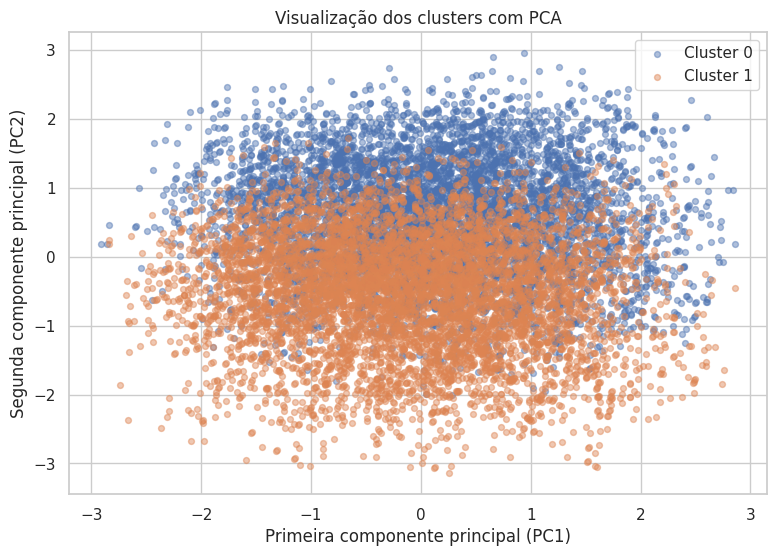

In [27]:
plt.figure(figsize=(9, 6))

for cluster in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        alpha=0.45,
        s=18,
        label=f"Cluster {cluster}"
    )

plt.title("Visualização dos clusters com PCA")
plt.xlabel("Primeira componente principal (PC1)")
plt.ylabel("Segunda componente principal (PC2)")
plt.legend()
plt.show()

Pontos próximos possuem perfis semelhantes na projeção.

Sobreposição entre cores indica que os grupos não são perfeitamente separados. Isso é comum em dados educacionais, pois perfis humanos formam transições contínuas e não caixas completamente isoladas.

# 15. Clusterização hierárquica

A clusterização hierárquica começa considerando cada observação como um grupo separado. Em seguida, une progressivamente os grupos mais semelhantes.

Como um dendrograma com milhares de registros fica ilegível e computacionalmente pesado, utilizaremos uma amostra.

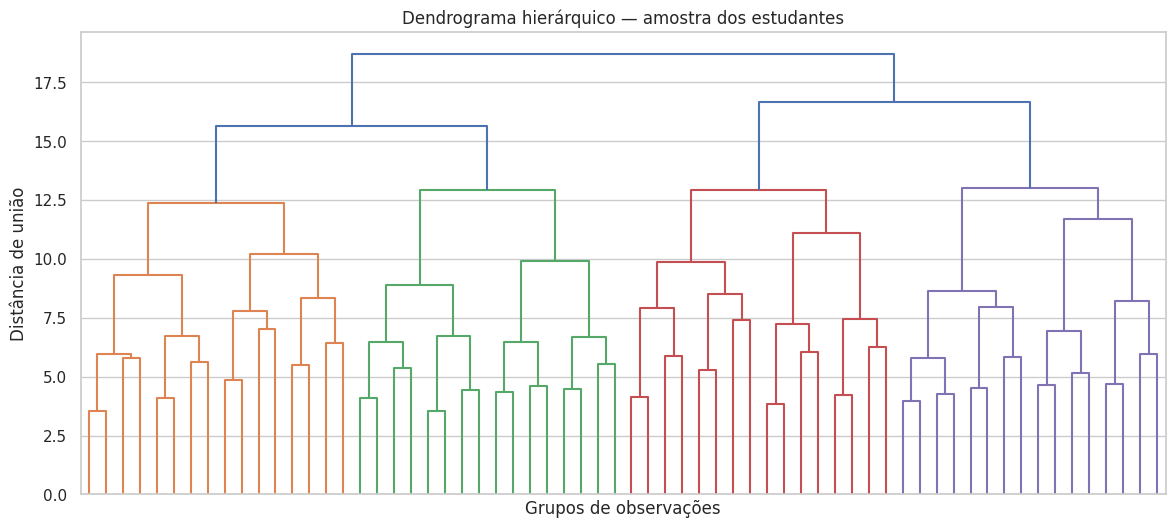

In [28]:
sample_size = min(300, len(df_clustered))
sample_indices = df_clustered.sample(
    n=sample_size,
    random_state=RANDOM_STATE
).index

X_sample = X_processed[sample_indices]

linkage_matrix = linkage(
    X_sample.toarray() if hasattr(X_sample, "toarray") else X_sample,
    method="ward"
)

plt.figure(figsize=(14, 6))
dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=5,
    no_labels=True
)
plt.title("Dendrograma hierárquico — amostra dos estudantes")
plt.xlabel("Grupos de observações")
plt.ylabel("Distância de união")
plt.show()

### Parâmetros principais

- `method="ward"`: une grupos buscando o menor aumento da variância interna;
- `truncate_mode="level"`: resume níveis inferiores do dendrograma;
- `p=5`: exibe apenas uma parte da árvore;
- eixo Y: distância na qual os grupos foram unidos.

Grandes saltos verticais podem sugerir divisões naturais.

## 15.1 Comparação com Agglomerative Clustering

In [29]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=k_final,
    linkage="ward"
)

# O modelo hierárquico é aplicado à mesma amostra usada no dendrograma,
# evitando o custo quadrático sobre todo o dataset.
hierarchical_labels = hierarchical_model.fit_predict(
    X_sample.toarray() if hasattr(X_sample, "toarray") else X_sample
)

kmeans_sample_labels = kmeans.predict(X_sample)

hierarchical_silhouette = silhouette_score(X_sample, hierarchical_labels)
kmeans_sample_silhouette = silhouette_score(X_sample, kmeans_sample_labels)

print(
    "Silhouette do K-Means na amostra:",
    round(kmeans_sample_silhouette, 4)
)

print(
    "Silhouette do modelo hierárquico na amostra:",
    round(hierarchical_silhouette, 4)
)

Silhouette do K-Means na amostra: 0.0768
Silhouette do modelo hierárquico na amostra: 0.0536


Essa comparação não significa que o algoritmo com maior Silhouette seja sempre o melhor.

Também devem ser considerados:

- interpretabilidade;
- tempo de execução;
- estabilidade;
- formato esperado dos clusters;
- aplicação prática.

# 16. Sugestão automática de interpretação

In [30]:
overall_means = df_clustered[profile_columns].mean()
relative_profile = cluster_profile[profile_columns].subtract(overall_means)

summary_rows = []

for cluster in cluster_profile.index:
    row = relative_profile.loc[cluster]

    strongest_positive = row.sort_values(ascending=False).head(3).index.tolist()
    strongest_negative = row.sort_values().head(3).index.tolist()

    summary_rows.append({
        "Cluster": cluster,
        "Acima da média principalmente em": ", ".join(strongest_positive),
        "Abaixo da média principalmente em": ", ".join(strongest_negative),
        "ExamScore médio": cluster_profile.loc[cluster, "ExamScore"],
        "FinalGrade médio": cluster_profile.loc[cluster, "FinalGrade"]
    })

automatic_summary = pd.DataFrame(summary_rows).set_index("Cluster")
automatic_summary

,Acima da média principalmente em,Abaixo da média principalmente em,ExamScore médio,FinalGrade médio
Cluster,,,,
0,"AssignmentCompletion, ExamScore, StudyHours","Age, Attendance, FinalGrade",70.95,1.41
1,"Age, Attendance, FinalGrade","AssignmentCompletion, ExamScore, StudyHours",69.73,1.49


Essa tabela não substitui a análise humana. Ela apenas destaca as maiores diferenças absolutas em relação à média geral.

Depois de observar os resultados, o analista pode criar nomes descritivos, como:

- “alto engajamento e bom desempenho”;
- “baixa frequência e baixa conclusão”;
- “uso intenso de recursos digitais”;
- “alto esforço com elevado estresse”.

Os nomes devem refletir os valores realmente encontrados no notebook.

# 17. Como usar os clusters

Os clusters podem apoiar decisões educacionais, por exemplo:

- oferecer reforço para grupos com baixa frequência e baixo desempenho;
- criar estratégias de redução de estresse;
- incentivar cursos on-line para estudantes com baixa adesão digital;
- oferecer desafios adicionais a estudantes muito engajados;
- personalizar comunicação e acompanhamento.

### Cuidado ético

Clusters não devem ser usados para rotular permanentemente pessoas.

Um cluster descreve uma semelhança estatística dentro deste conjunto de dados. Ele não define a capacidade, personalidade ou futuro de um estudante.

# 18. Limitações do projeto

1. **Códigos categóricos sem dicionário:** não sabemos o significado textual exato de todos os códigos;
2. **Possíveis duplicatas legítimas:** não existe identificador único;
3. **K-Means favorece grupos aproximadamente esféricos:** formatos complexos podem não ser bem representados;
4. **Escolha de `k`:** não existe uma resposta totalmente objetiva;
5. **Dados comportamentais:** os grupos podem apresentar bastante sobreposição;
6. **Sem validação externa:** não há uma categoria verdadeira para comparar;
7. **PCA perde informação:** duas dimensões não representam toda a estrutura original;
8. **Clusters dependem das variáveis escolhidas:** outro conjunto de características pode produzir grupos diferentes.

# 19. Conclusão

In [31]:
final_silhouette = silhouette_score(
    X_processed,
    df_clustered["Cluster"]
)

print(f"Quantidade escolhida de clusters: {k_final}")
print(f"Silhouette Score final: {final_silhouette:.4f}")
print()
print("Tamanho dos clusters:")
display(cluster_sizes)
print()
print("Perfil médio:")
display(cluster_profile)

Quantidade escolhida de clusters: 2
Silhouette Score final: 0.0713

Tamanho dos clusters:


,Quantidade,Percentual
Cluster,,
0,5925,47.52
1,6544,52.48



Perfil médio:


,StudyHours,Attendance,Resources,Motivation,Age,OnlineCourses,AssignmentCompletion,StressLevel,ExamScore,FinalGrade
Cluster,,,,,,,,,,
0,20.4,80.03,1.18,0.95,23.25,9.96,87.58,1.32,70.95,1.41
1,19.7,80.43,1.03,0.87,23.78,9.79,62.69,1.29,69.73,1.49


# 20. Glossário de funções utilizadas

| Função/objeto | Finalidade |
|---|---|
| `pd.read_csv()` | Ler o arquivo CSV |
| `copy()` | Criar uma cópia independente |
| `head()` | Mostrar as primeiras linhas |
| `info()` | Mostrar estrutura e tipos |
| `describe()` | Calcular estatísticas descritivas |
| `isna()` | Identificar valores ausentes |
| `duplicated()` | Identificar linhas duplicadas |
| `drop_duplicates()` | Remover duplicatas |
| `groupby()` | Agrupar linhas por categoria |
| `mean()` | Calcular média |
| `value_counts()` | Contar categorias |
| `pd.crosstab()` | Criar tabela cruzada |
| `StandardScaler()` | Padronizar variáveis numéricas |
| `OneHotEncoder()` | Codificar categorias |
| `ColumnTransformer()` | Aplicar transformações por coluna |
| `KMeans()` | Criar clusters por centroides |
| `fit_predict()` | Treinar e retornar rótulos |
| `silhouette_score()` | Avaliar coesão e separação |
| `PCA()` | Reduzir dimensionalidade |
| `linkage()` | Construir hierarquia de agrupamento |
| `dendrogram()` | Visualizar hierarquia |
| `AgglomerativeClustering()` | Criar clusters hierárquicos |